## Time Series Forecasting with Prophet model

Data source: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from prophet import Prophet

from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# plt.style.use('ggplot')
# plt.style.use('fivethirtyeight')

In [2]:
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

#### Data

The data we will be using is hourly power consumption data from PJM. Energy consumption has some unique characteristics. It will be interesting to see how prophet picks them up.

Pulling the *PJM East* which has data from 2002-2018 for the entire east region.

In [3]:
pjme = pd.read_csv('archive/PJME_hourly.csv', index_col=[0], parse_dates=[0])

pjme.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


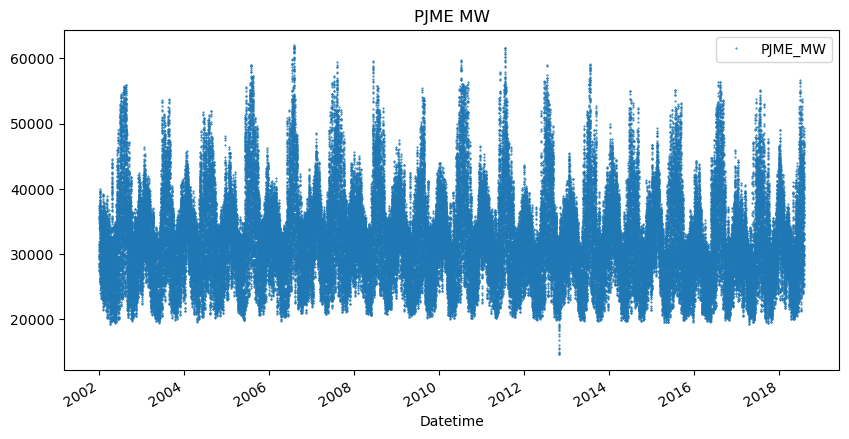

In [4]:
pjme.plot(style='.', figsize=(10,5), ms=1, title='PJME MW')
plt.show()

#### Time Series Features

In [8]:
from pandas.api.types import CategoricalDtype

cat_type = CategoricalDtype(categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)

def create_features(df, label=None):
    """
    Creates time series features from datetime index.
    """
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(cat_type)
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    df['date_offset'] = (df['date'].dt.month*100 + df['date'].dt.day - 320)%1300
    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300], labels=['Spring', 'Summer', 'Fall', 'Winter'])

    X = df[['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear', 'weekday', 'season']]

    if label:
        y = df[label]
        return X, y

X, y = create_features(pjme, label='PJME_MW')

features_and_target = pd.concat([X, y], axis=1)

In [9]:
features_and_target

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,weekday,season,PJME_MW
Datetime,,,,,,,,,,,
2002-12-31 01:00:00,1,1,4,12,2002,365,31,1,Tuesday,Winter,26498.0
2002-12-31 02:00:00,2,1,4,12,2002,365,31,1,Tuesday,Winter,25147.0
2002-12-31 03:00:00,3,1,4,12,2002,365,31,1,Tuesday,Winter,24574.0
2002-12-31 04:00:00,4,1,4,12,2002,365,31,1,Tuesday,Winter,24393.0
2002-12-31 05:00:00,5,1,4,12,2002,365,31,1,Tuesday,Winter,24860.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,20,0,1,1,2018,1,1,1,Monday,Winter,44284.0
2018-01-01 21:00:00,21,0,1,1,2018,1,1,1,Monday,Winter,43751.0
2018-01-01 22:00:00,22,0,1,1,2018,1,1,1,Monday,Winter,42402.0


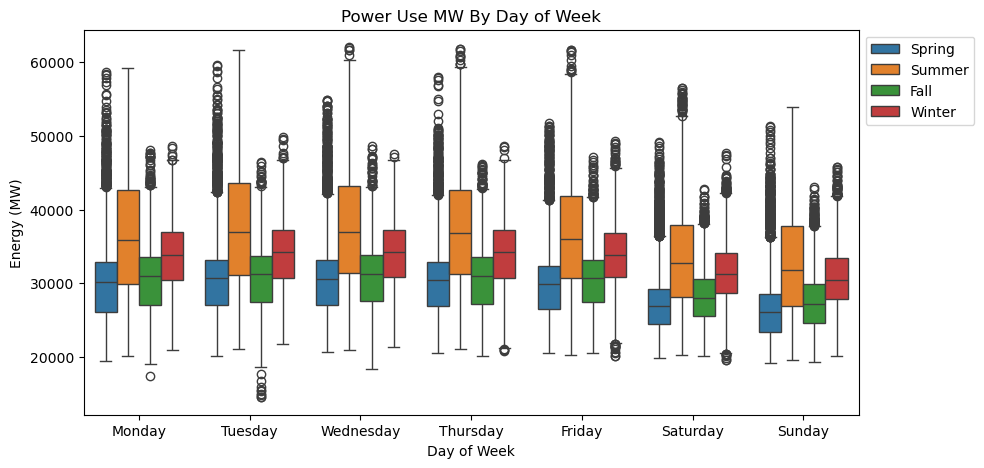

In [10]:
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=features_and_target.dropna(),
           x='weekday',
           y='PJME_MW',
           hue='season',
           ax=ax,
           linewidth=1)

ax.set_title('Power Use MW By Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Energy (MW)')
ax.legend(bbox_to_anchor=(1,1))
plt.show()

#### Train/test split

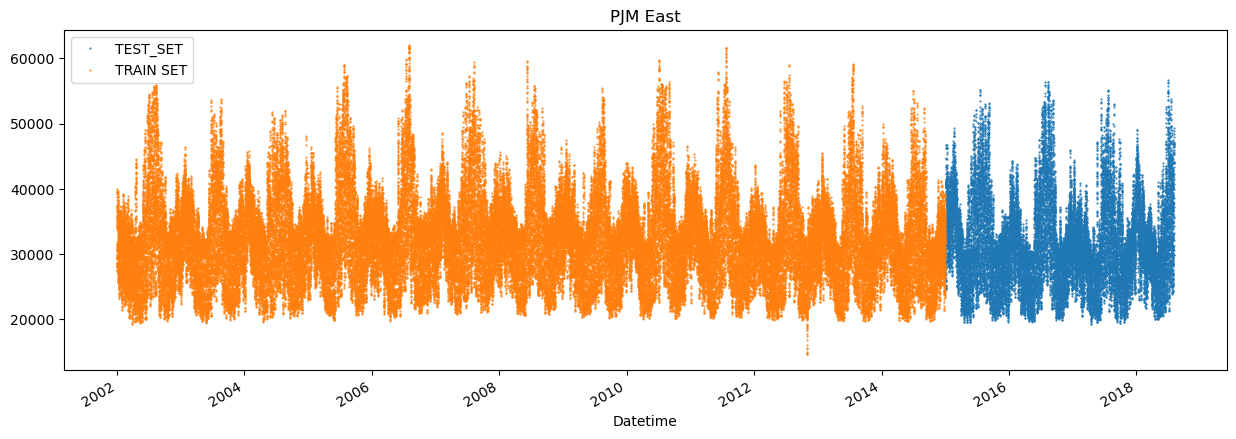

In [15]:
split_date = '1-Jan-2015'
pjme_train = pjme.loc[pjme.index <= split_date].copy()
pjme_test = pjme.loc[pjme.index > split_date].copy()

# Plot train and test so you can see where we have split
pjme_test.rename(columns={'PJME_MW': 'TEST_SET'}). \
    join(pjme_train.rename(columns={'PJME_MW': 'TRAIN SET'}), how='outer'). \
        plot(figsize=(15,5), title='PJM East', style='.', ms=1)
plt.show()

### Simple Prophet Model

Prophet model expects the dataset to be named a specific way. We will rename our dataframe columns before feeding it into the model.

* Datetime column named: `ds`
* target: `y`

In [16]:
# Format data for prophet model using ds and y
pjme_train_prophet = pjme_train.reset_index().rename(columns={'Datetime': 'ds', 'PJME_MW': 'y'})

In [17]:
pjme_train_prophet.head()

,ds,y
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [18]:
%%time
model = Prophet()
model.fit(pjme_train_prophet)

10:23:54 - cmdstanpy - INFO - Chain [1] start processing
10:25:05 - cmdstanpy - INFO - Chain [1] done processing


CPU times: user 8.28 s, sys: 348 ms, total: 8.63 s
Wall time: 1min 19s


In [20]:
# Predict on test set with model
pjme_test_prophet = pjme_test.reset_index().rename(columns={'Datetime':'ds', 'PJME_MW':'y'})

pjme_test_fcst = model.predict(pjme_test_prophet)

In [21]:
pjme_test_fcst.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01 01:00:00,31210.828952,24022.783340,32784.812079,31210.828952,31210.828952,-2893.744621,-2893.744621,-2893.744621,-4430.274886,...,1281.327002,1281.327002,1281.327002,255.203263,255.203263,255.203263,0.0,0.0,0.0,28317.084331
1,2015-01-01 02:00:00,31210.792144,22854.019532,31291.263474,31210.792144,31210.792144,-4398.241671,-4398.241671,-4398.241671,-5927.275057,...,1272.572288,1272.572288,1272.572288,256.461099,256.461099,256.461099,0.0,0.0,0.0,26812.550473
2,2015-01-01 03:00:00,31210.755336,21267.543212,30260.670638,31210.755336,31210.755336,-5269.976752,-5269.976752,-5269.976752,-6790.348728,...,1262.611487,1262.611487,1262.611487,257.760489,257.760489,257.760489,0.0,0.0,0.0,25940.778583
3,2015-01-01 04:00:00,31210.718527,21319.621782,30477.126793,31210.718527,31210.718527,-5411.458676,-5411.458676,-5411.458676,-6922.128354,...,1251.568218,1251.568218,1251.568218,259.101460,259.101460,259.101460,0.0,0.0,0.0,25799.259851
4,2015-01-01 05:00:00,31210.681719,22114.183829,30937.557127,31210.681719,31210.681719,-4737.020385,-4737.020385,-4737.020385,-6237.082737,...,1239.578314,1239.578314,1239.578314,260.484037,260.484037,260.484037,0.0,0.0,0.0,26473.661334


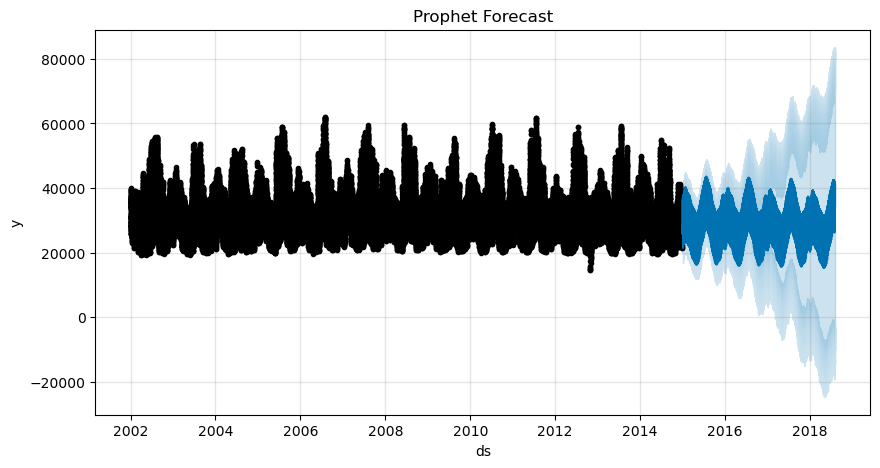

In [24]:
fig, ax = plt.subplots(figsize=(10,5))
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_title('Prophet Forecast')
plt.show()

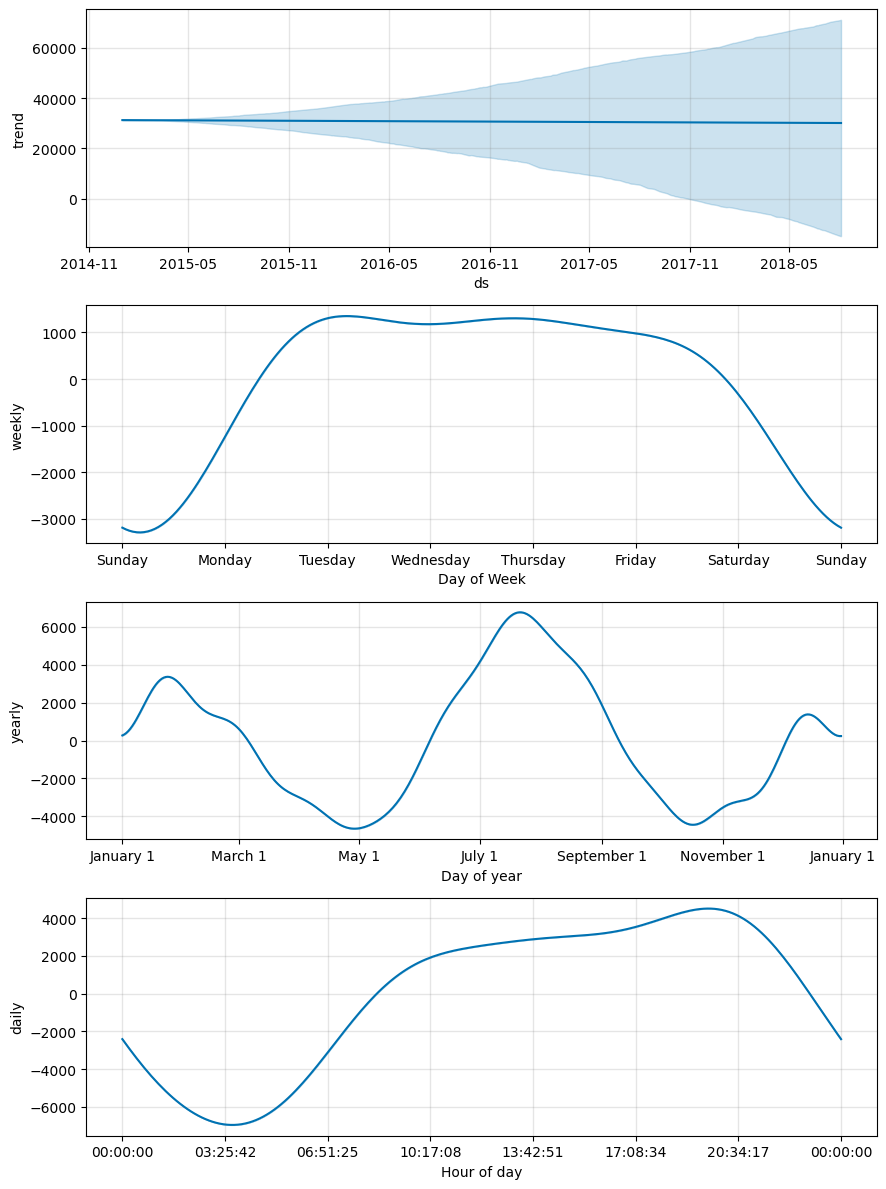

In [25]:
model.plot_components(pjme_test_fcst)
plt.show()

#### Compare Forecast to Actuals

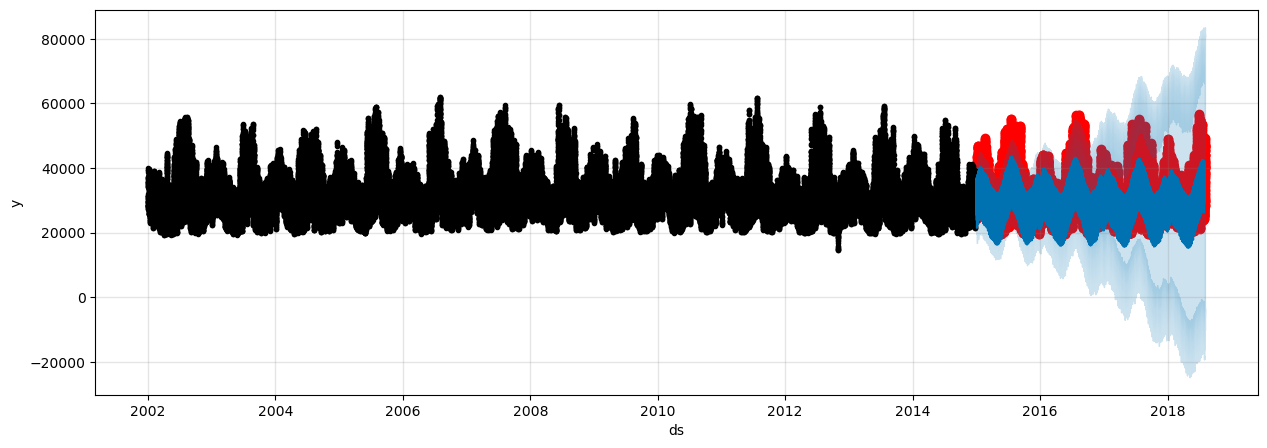

In [26]:
# Plot the forecast with the actuals
f, ax = plt.subplots(figsize=(15,5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)

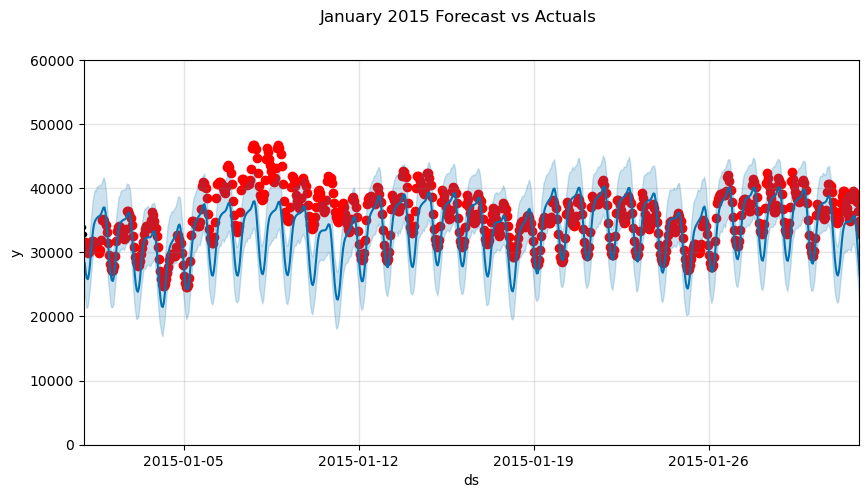

In [35]:
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_xbound(lower=pd.Timestamp('2015-01-01'), upper=pd.Timestamp('2015-02-01'))
ax.set_ylim(0, 60000)
plot = plt.suptitle('January 2015 Forecast vs Actuals')

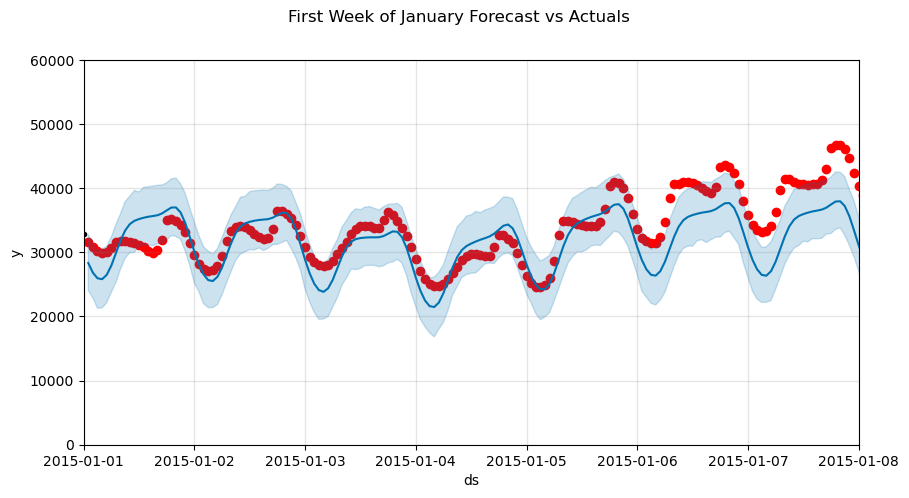

In [36]:
# Plot the forecast with the actuals
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_xbound(lower=pd.Timestamp('2015-01-01'), upper=pd.Timestamp('2015-01-08'))
ax.set_ylim(0, 60000)
plot = plt.suptitle('First Week of January Forecast vs Actuals')

#### Evaluate the model with Error Metrics

In [37]:
np.sqrt(mean_squared_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test_fcst['yhat']))

np.float64(6616.929727126127)

In [39]:
mean_absolute_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test_fcst['yhat'])

5181.902492927458

In [40]:
mean_absolute_percentage_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test_fcst['yhat'])

np.float64(16.512083240542825)

#### Adding Holidays

Next we will see if adding holiday indicators will help the accuracy of the model. Prophet comes with a Holiday Effects parameter that can be provided to the model prior to training.

We will use the built in pandas USFederalHolidayCalendar to pull the list of holidays.

In [63]:
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

cal = calendar()

holidays = cal.holidays(start=pjme.index.min(), end=pjme.index.max(), return_name=True)

holiday_df = pd.DataFrame(data=holidays, columns=['holiday'])

In [64]:
holidays

2002-01-21    Birthday of Martin Luther King, Jr.
2002-02-18                  Washington's Birthday
2002-05-27                           Memorial Day
2002-07-04                       Independence Day
2002-09-02                              Labor Day
                             ...                 
2018-01-01                         New Year's Day
2018-01-15    Birthday of Martin Luther King, Jr.
2018-02-19                  Washington's Birthday
2018-05-28                           Memorial Day
2018-07-04                       Independence Day
Length: 164, dtype: object

In [65]:
holiday_df

,holiday
2002-01-21,"Birthday of Martin Luther King, Jr."
2002-02-18,Washington's Birthday
2002-05-27,Memorial Day
2002-07-04,Independence Day
2002-09-02,Labor Day
...,...
2018-01-01,New Year's Day
2018-01-15,"Birthday of Martin Luther King, Jr."
2018-02-19,Washington's Birthday
2018-05-28,Memorial Day


In [67]:
holiday_df['holiday'].value_counts()

holiday
Birthday of Martin Luther King, Jr.    17
Washington's Birthday                  17
Memorial Day                           17
Independence Day                       17
Labor Day                              16
Columbus Day                           16
Veterans Day                           16
Thanksgiving Day                       16
Christmas Day                          16
New Year's Day                         16
Name: count, dtype: int64

In [68]:
holiday_df = holiday_df.reset_index().rename(columns={'index': 'ds'})

In [69]:
holiday_df.head()

,ds,holiday
0,2002-01-21,"Birthday of Martin Luther King, Jr."
1,2002-02-18,Washington's Birthday
2,2002-05-27,Memorial Day
3,2002-07-04,Independence Day
4,2002-09-02,Labor Day


In [70]:
%%time
model_with_holidays = Prophet(holidays=holiday_df)
model_with_holidays.fit(pjme_train_prophet)

11:23:29 - cmdstanpy - INFO - Chain [1] start processing
11:25:29 - cmdstanpy - INFO - Chain [1] done processing


CPU times: user 9.92 s, sys: 297 ms, total: 10.2 s
Wall time: 2min 9s


In [71]:
# Predict on training set with model
pjme_test_fcst_with_hols = model_with_holidays.predict(df=pjme_test_prophet)

In [73]:
pjme_test_fcst_with_hols.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,"Birthday of Martin Luther King, Jr.","Birthday of Martin Luther King, Jr._lower","Birthday of Martin Luther King, Jr._upper",Christmas Day,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01 01:00:00,31244.064077,21327.667351,30137.446277,31244.064077,31244.064077,0.0,0.0,0.0,0.0,...,1324.562728,1324.562728,1324.562728,674.242760,674.242760,674.242760,0.0,0.0,0.0,25566.734542
1,2015-01-01 02:00:00,31244.024466,19863.798991,28702.348678,31244.024466,31244.024466,0.0,0.0,0.0,0.0,...,1318.788660,1318.788660,1318.788660,675.208238,675.208238,675.208238,0.0,0.0,0.0,24064.813557
2,2015-01-01 03:00:00,31243.984855,18440.127102,27431.258787,31243.984855,31243.984855,0.0,0.0,0.0,0.0,...,1311.472925,1311.472925,1311.472925,676.207479,676.207479,676.207479,0.0,0.0,0.0,23195.290712
3,2015-01-01 04:00:00,31243.945244,18330.989571,27664.682153,31243.945244,31243.945244,0.0,0.0,0.0,0.0,...,1302.726305,1302.726305,1302.726305,677.240520,677.240520,677.240520,0.0,0.0,0.0,23055.674425
4,2015-01-01 05:00:00,31243.905634,19061.531965,28057.895938,31243.905634,31243.905634,0.0,0.0,0.0,0.0,...,1292.675465,1292.675465,1292.675465,678.307399,678.307399,678.307399,0.0,0.0,0.0,23731.654437


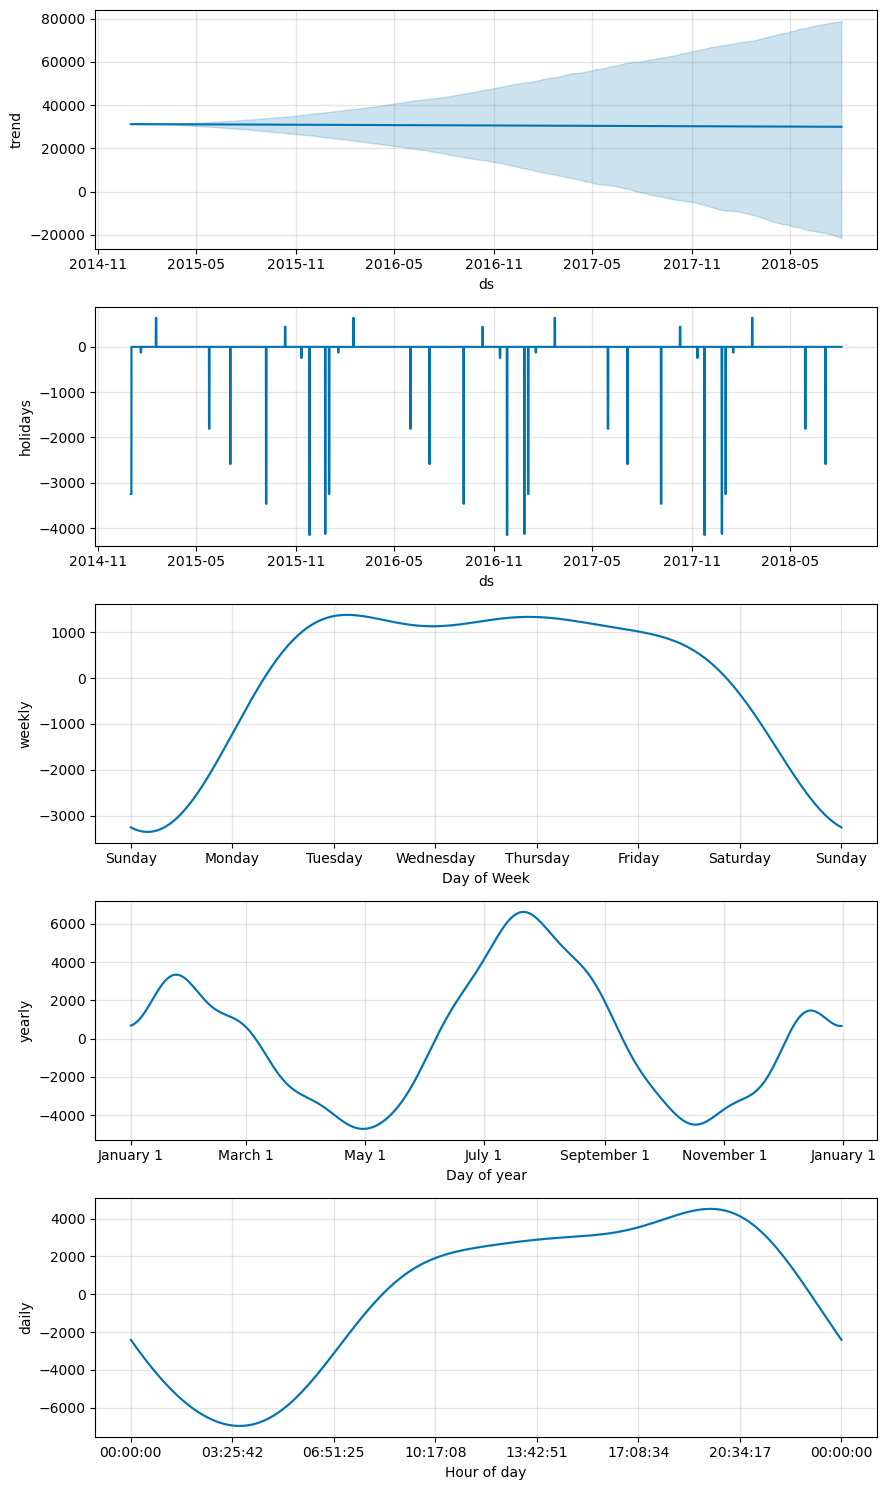

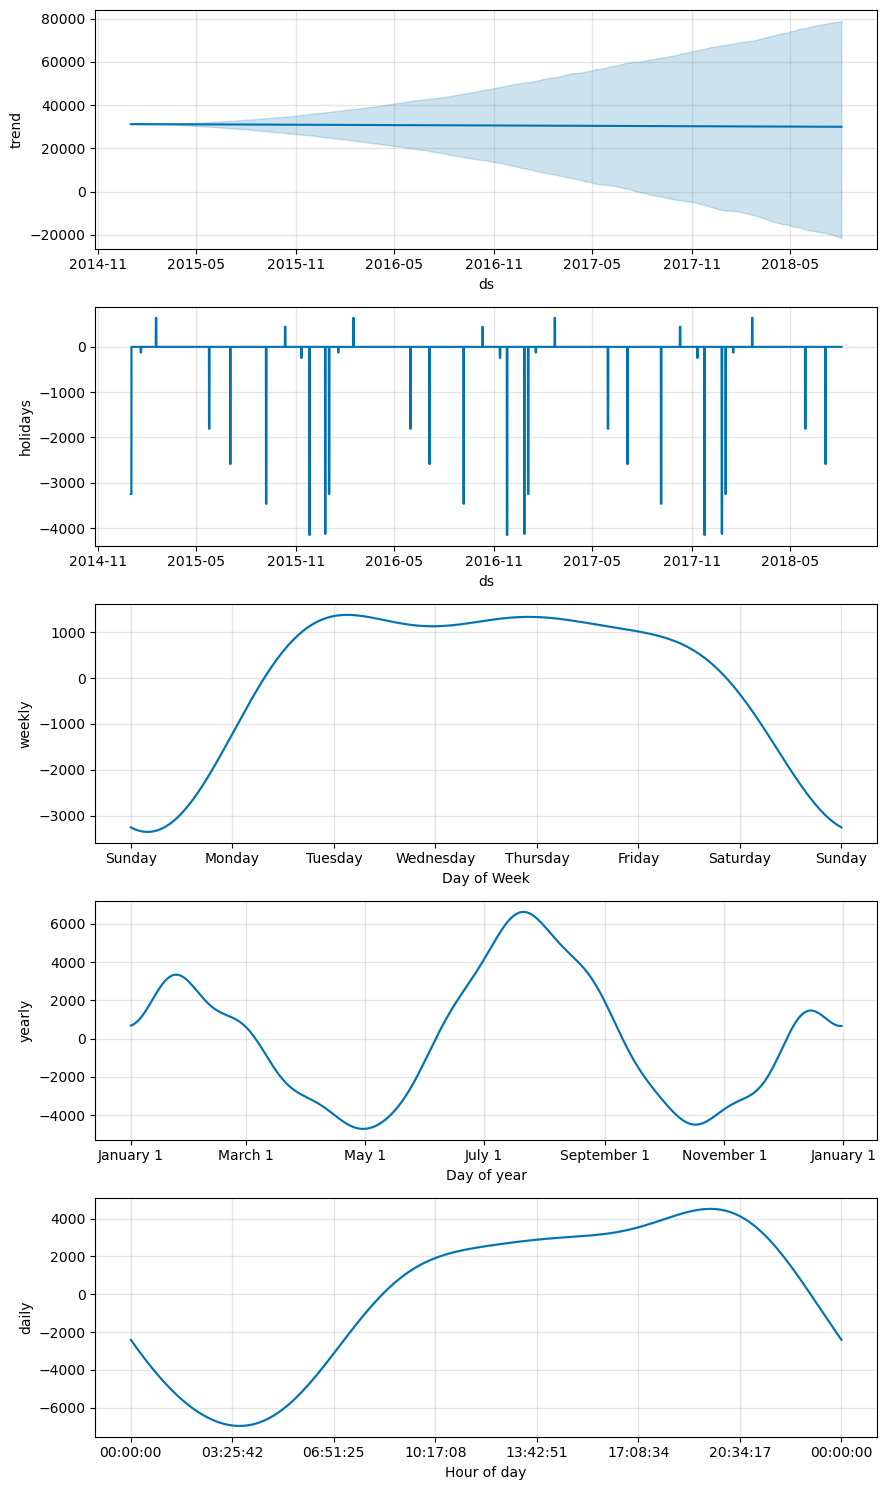

In [72]:
model_with_holidays.plot_components(
    pjme_test_fcst_with_hols
)

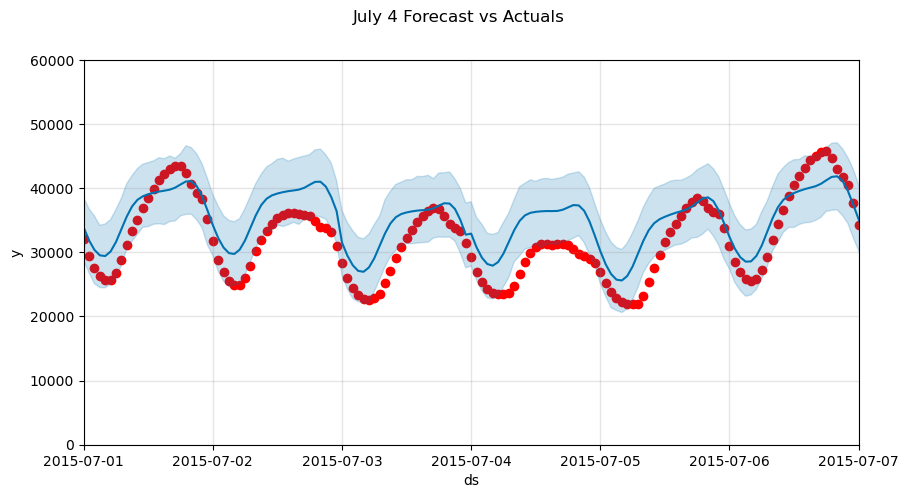

In [74]:
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r')
fig = model.plot(pjme_test_fcst_with_hols, ax=ax)
ax.set_xbound(lower=pd.Timestamp('2015-07-01'), 
              upper=pd.Timestamp('2015-07-07'))
ax.set_ylim(0, 60000)
plot = plt.suptitle('July 4 Forecast vs Actuals')

In [78]:
np.sqrt(mean_squared_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test_fcst_with_hols['yhat']))

np.float64(6639.651762773761)

In [79]:
mean_absolute_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test_fcst_with_hols['yhat'])

5201.481641082228

In [80]:
mean_absolute_percentage_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test_fcst_with_hols['yhat'])

np.float64(16.558679824986203)

#### Predict into the future

In [82]:
future = model.make_future_dataframe(periods=365*24, freq='h', include_history=False)
forecast = model_with_holidays.predict(future)

In [83]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,"Birthday of Martin Luther King, Jr.","Birthday of Martin Luther King, Jr._lower","Birthday of Martin Luther King, Jr._upper",Christmas Day,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01 01:00:00,31244.064077,21342.701198,30082.873916,31244.064077,31244.064077,0.0,0.0,0.0,0.0,...,1324.562728,1324.562728,1324.562728,674.242760,674.242760,674.242760,0.0,0.0,0.0,25566.734542
1,2015-01-01 02:00:00,31244.024466,19432.546489,28436.471561,31244.024466,31244.024466,0.0,0.0,0.0,0.0,...,1318.788660,1318.788660,1318.788660,675.208238,675.208238,675.208238,0.0,0.0,0.0,24064.813557
2,2015-01-01 03:00:00,31243.984855,18498.093838,27292.740518,31243.984855,31243.984855,0.0,0.0,0.0,0.0,...,1311.472925,1311.472925,1311.472925,676.207479,676.207479,676.207479,0.0,0.0,0.0,23195.290712
3,2015-01-01 04:00:00,31243.945244,18641.578775,27618.464583,31243.945244,31243.945244,0.0,0.0,0.0,0.0,...,1302.726305,1302.726305,1302.726305,677.240520,677.240520,677.240520,0.0,0.0,0.0,23055.674425
4,2015-01-01 05:00:00,31243.905634,19111.892728,28286.057825,31243.905634,31243.905634,0.0,0.0,0.0,0.0,...,1292.675465,1292.675465,1292.675465,678.307399,678.307399,678.307399,0.0,0.0,0.0,23731.654437


In [84]:
forecast['yhat']

0       25566.734542
1       24064.813557
2       23195.290712
3       23055.674425
4       23731.654437
            ...     
8755    37090.950352
8756    36321.189539
8757    34695.007809
8758    32490.237383
8759    26921.624875
Name: yhat, Length: 8760, dtype: float64